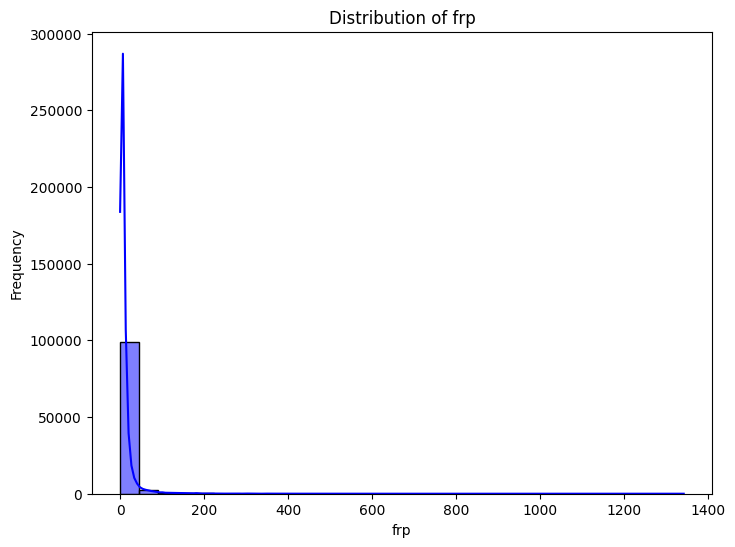

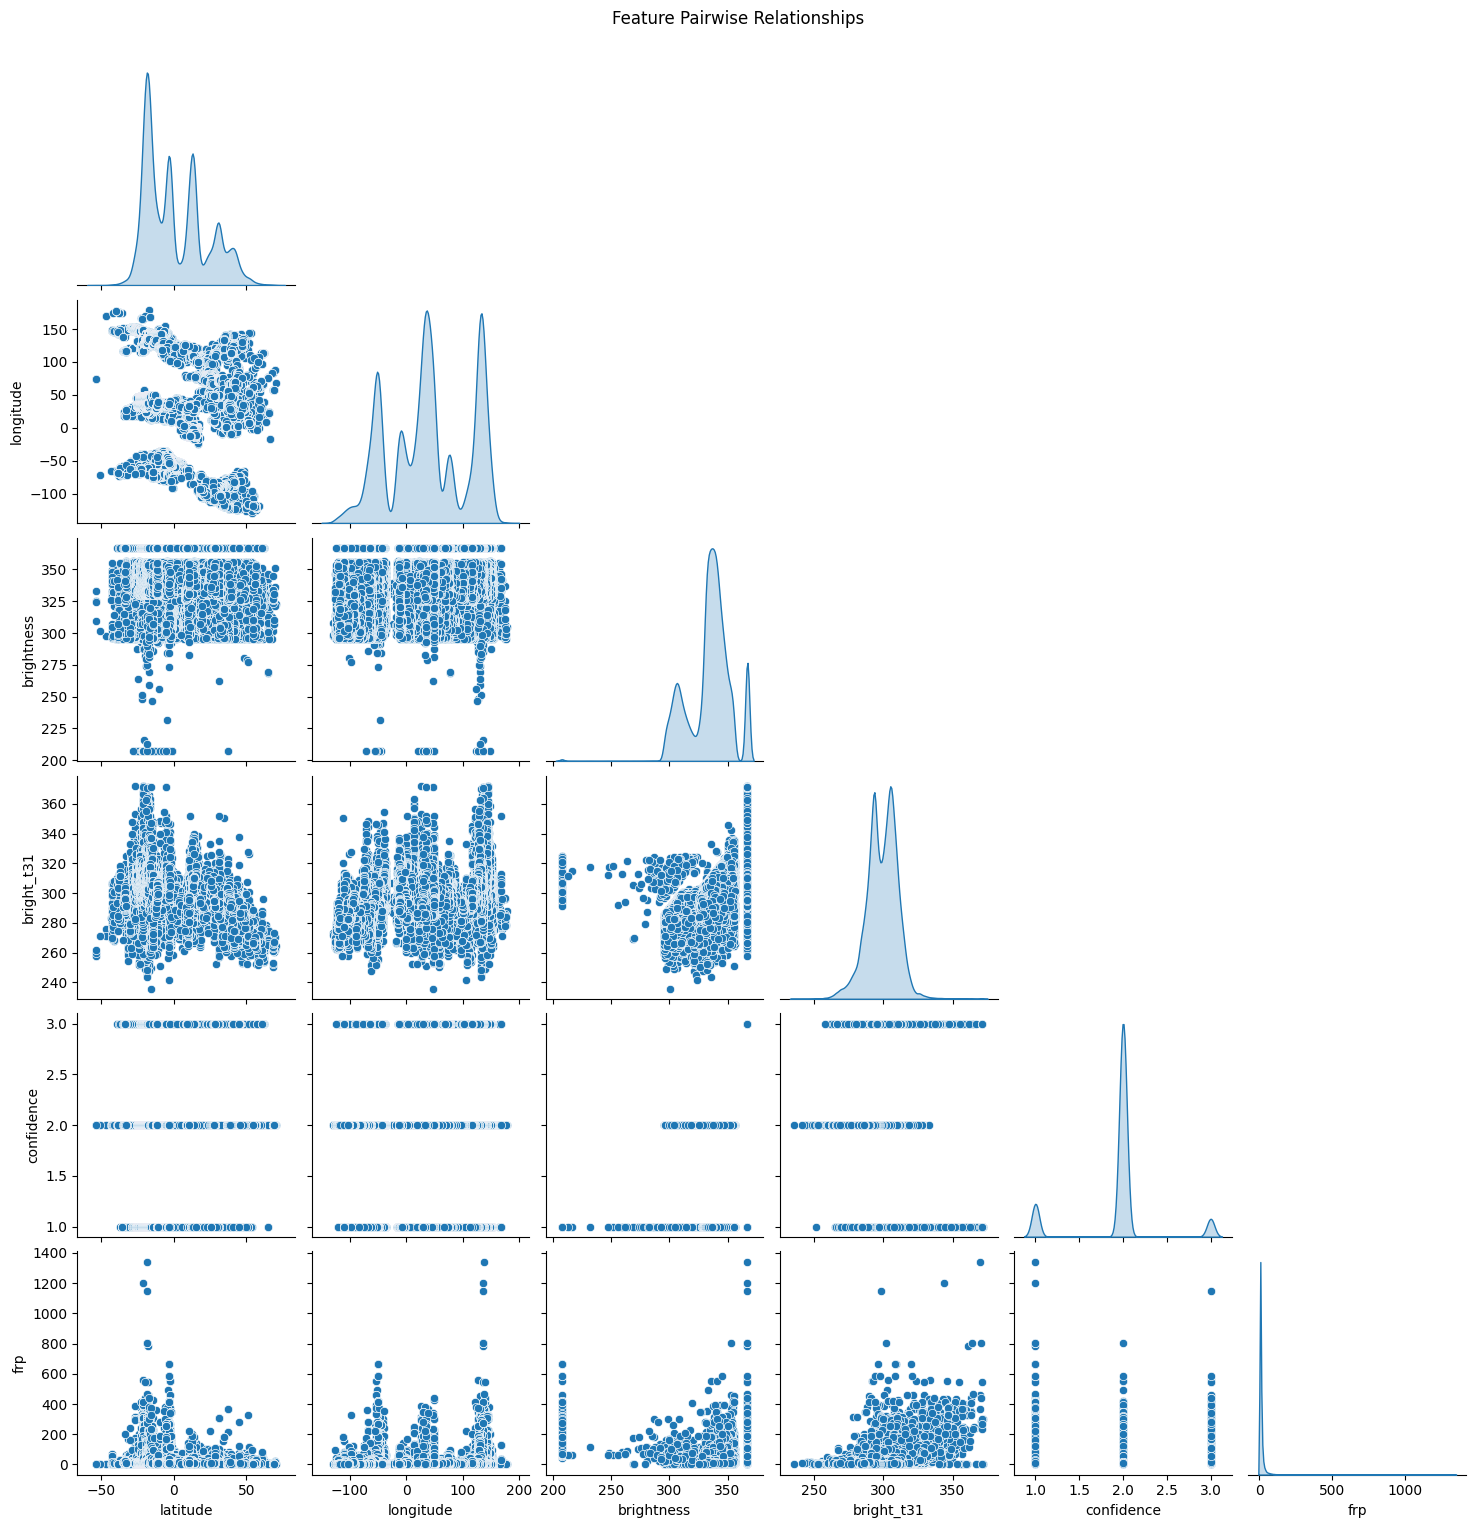

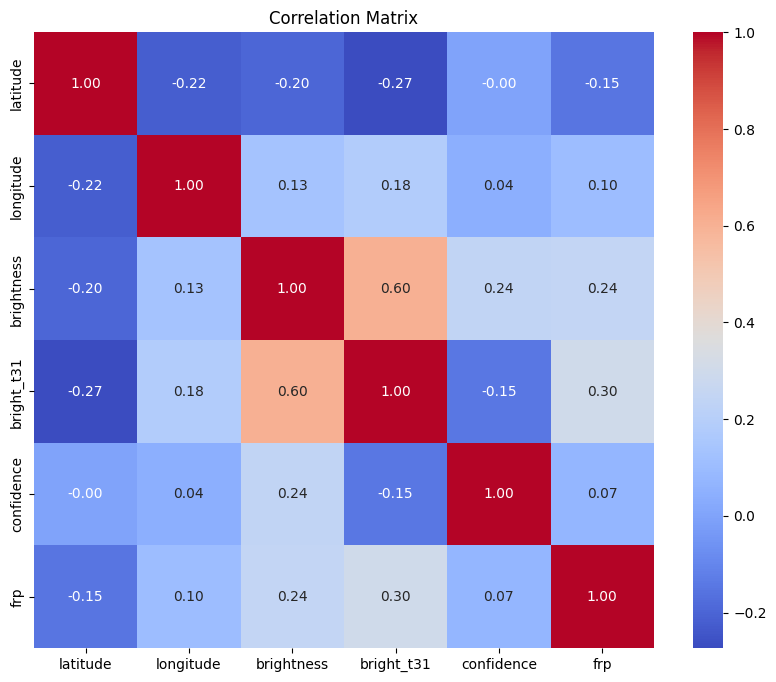

Training set shape: (82456, 5)
Testing set shape: (20614, 5)


In [ ]:
# Data Preparation for Random Forest with XAI (No Graphs)

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
def load_data(file_path):
    """Load dataset from a CSV file."""
    data = pd.read_csv(file_path)
    return data

# Data Cleaning
def clean_data(data):
    """Clean the dataset by handling missing and invalid values."""
    # Handle invalid values in 'confidence' column
    confidence_mapping = {'l': 1, 'n': 2, 'h': 3}  # Map confidence levels to numeric values
    if 'confidence' in data.columns:
        data['confidence'] = data['confidence'].map(confidence_mapping)

    # Check for missing values and handle them (drop rows with missing target values)
    data = data.dropna(subset=['frp'])

    # Fill or drop rows with missing values in features
    # data.fillna(data.mean(), inplace=True)

    return data

# Feature Transformation for Skewness
def transform_target(data, target):
    """Transform the target variable to handle skewness."""
    transformer = PowerTransformer(method='yeo-johnson')
    data[target] = transformer.fit_transform(data[[target]])
    return data, transformer

# Feature Scaling
def scale_features(data, features):
    """Scale selected features using MinMaxScaler."""
    scaler = MinMaxScaler()
    data[features] = scaler.fit_transform(data[features])
    return data, scaler

# Train-Test Split
def split_data(data, features, target):
    """Split the dataset into training and testing sets."""
    X = data[features]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    return X_train, X_test, y_train, y_test

# Data Visualization for EDA
def visualize_data(data, features, target):
    """Visualize the dataset with plots for EDA."""
    # Distribution of target variable
    plt.figure(figsize=(8, 6))
    sns.histplot(data[target], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {target}")
    plt.xlabel(target)
    plt.ylabel("Frequency")
    plt.show()

    # Pairplot for feature relationships
    sns.pairplot(data[features + [target]], diag_kind='kde', corner=True)
    plt.suptitle("Feature Pairwise Relationships", y=1.02)
    plt.show()

    # Correlation heatmap
    plt.figure(figsize=(10, 8))
    correlation_matrix = data[features + [target]].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title("Correlation Matrix")
    plt.show()

# Main cleaning and preparation pipeline
def prepare_data(file_path):
    """Load, clean, and prepare data for modeling."""
    data = load_data(file_path)

    # Relevant columns
    features = ['latitude', 'longitude', 'brightness', 'bright_t31', 'confidence']
    target = 'frp'

    # Clean data
    data = clean_data(data)

    # Visualize data
    visualize_data(data, features, target)

    # Transform target for skewness
    data, transformer = transform_target(data, target)

    # Scale features
    data, scaler = scale_features(data, features)

    # Train-test split
    X_train, X_test, y_train, y_test = split_data(data, features, target)

    return X_train, X_test, y_train, y_test, scaler, transformer

# Example usage
file_path = 'fire_nrt_J2V-C2_538155(data1).csv'  # Path to dataset
X_train, X_test, y_train, y_test, scaler, transformer = prepare_data(file_path)

# Display prepared data shapes
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


## Lets save the prepared data

In [ ]:
# Save prepared training and testing datasets
def save_prepared_data(X_train, X_test, y_train, y_test, output_dir="prepared_data"):
    """Save preprocessed training and testing datasets to CSV files."""
    import os
    os.makedirs(output_dir, exist_ok=True)

    X_train.to_csv(f"{output_dir}/wildfire_X_train.csv", index=False)
    X_test.to_csv(f"{output_dir}/wildfire_X_test.csv", index=False)
    y_train.to_csv(f"{output_dir}/wildfire_y_train.csv", index=False)
    y_test.to_csv(f"{output_dir}/wildfire_y_test.csv", index=False)
    print(f"Prepared datasets saved in '{output_dir}'.")

# Save the datasets
save_prepared_data(X_train, X_test, y_train, y_test)


Prepared datasets saved in 'prepared_data'.


#### Training and prediction using XAI and RF

Mean Squared Error (MSE): 0.29
Root Mean Squared Error (RMSE): 0.54
R-squared (R2): 0.71


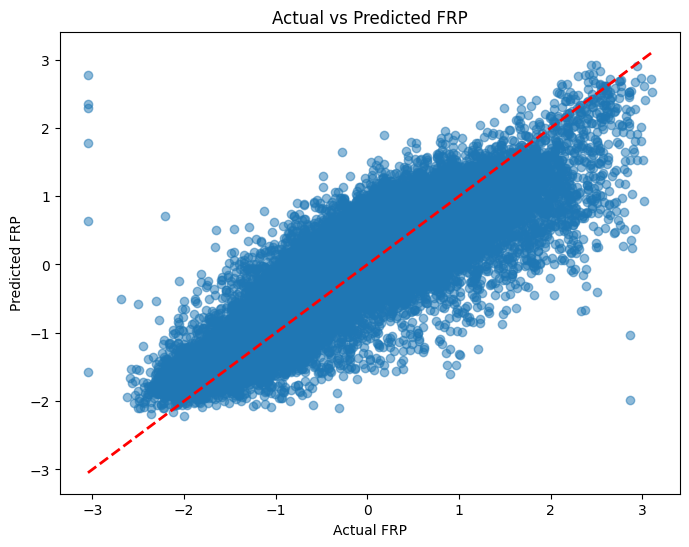

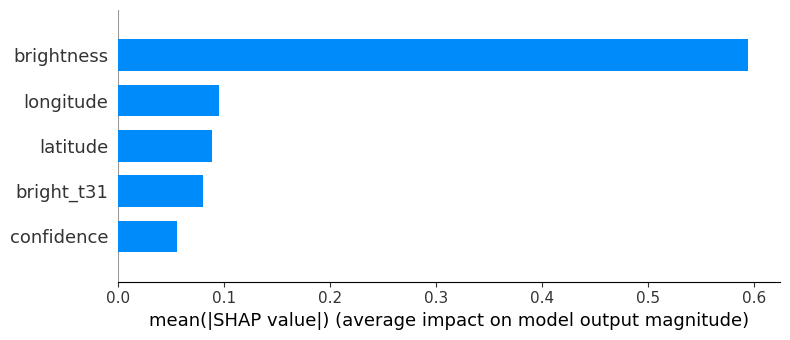

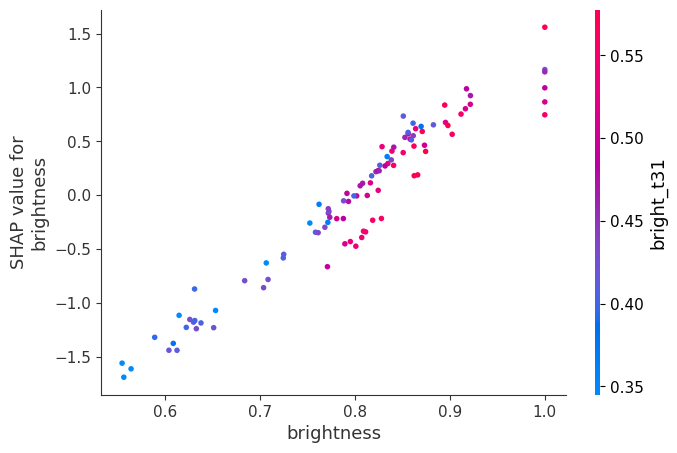

In [ ]:
# Train, Predict, and Explain Using Random Forest with Optimized XAI (SHAP)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap
import matplotlib.pyplot as plt
import numpy as np

# Train the Random Forest Model
def train_rf(X_train, y_train):
    """Train a Random Forest model."""
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

# Evaluate the Model
def evaluate_rf(model, X_test, y_test):
    """Make predictions and evaluate the model."""
    predictions = model.predict(X_test)

    # Calculate metrics
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R-squared (R2): {r2:.2f}")

    return predictions, mse, rmse, r2

# Optimize SHAP Analysis
def explain_model_with_shap(model, X_train, X_test):
    """Explain the model predictions using SHAP with optimizations."""
    # Use a sample of data for SHAP to improve performance
    X_sample = X_test.sample(n=100, random_state=42)

    # Use TreeExplainer for efficiency with tree-based models
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot for feature importance
    shap.summary_plot(shap_values, X_sample, plot_type="bar")

    # Dependence plot for a key feature (e.g., brightness)
    shap.dependence_plot("brightness", shap_values, X_sample)

# Visualization of Results
def plot_results(y_test, predictions):
    """Plot actual vs predicted values."""
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, predictions, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', linewidth=2)
    plt.title("Actual vs Predicted FRP")
    plt.xlabel("Actual FRP")
    plt.ylabel("Predicted FRP")
    plt.show()

# Example Workflow
# Assuming X_train, X_test, y_train, y_test are already prepared

# Train the Random Forest model
rf_model = train_rf(X_train, y_train)

# Evaluate the model
predictions, mse, rmse, r2 = evaluate_rf(rf_model, X_test, y_test)

# Plot results
plot_results(y_test, predictions)

# Explain model predictions using SHAP with optimizations
explain_model_with_shap(rf_model, X_train, X_test)
